<a href="https://colab.research.google.com/github/akhtaramina/CMPE-214-GPU-Architecture-and-Programming/blob/main/labs/lab2/214_lab02.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!nvidia-smi

Wed Sep  2 17:58:58 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   38C    P8              9W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [ ]:
%cd lab2

[Errno 2] No such file or directory: 'lab2'
/content


In [ ]:
!make

nvcc -arch=sm_52 main.cu -o vecadd
nvcc warning : Support for offline compilation for architectures prior to '<compute/sm/lto>_75' will be removed in a future release (Use -Wno-deprecated-gpu-targets to suppress warning).


In [ ]:
!./vecadd

In [ ]:
!make

nvcc -arch=sm_52 main.cu -o vecadd
nvcc warning : Support for offline compilation for architectures prior to '<compute/sm/lto>_75' will be removed in a future release (Use -Wno-deprecated-gpu-targets to suppress warning).


In [ ]:
!./vecadd

VecSize=256, blocks=1, threadsPerBlock=256, time=0.2230 ms
First 10 results:
C[0] = 0.000000 (A=0.000000 + B=0.000000)
C[1] = 2.000000 (A=1.000000 + B=1.000000)
C[2] = 4.000000 (A=2.000000 + B=2.000000)
C[3] = 6.000000 (A=3.000000 + B=3.000000)
C[4] = 8.000000 (A=4.000000 + B=4.000000)
C[5] = 10.000000 (A=5.000000 + B=5.000000)
C[6] = 12.000000 (A=6.000000 + B=6.000000)
C[7] = 14.000000 (A=7.000000 + B=7.000000)
C[8] = 16.000000 (A=8.000000 + B=8.000000)
C[9] = 18.000000 (A=9.000000 + B=9.000000)
SUCCESS: all 256 elements correct


In [ ]:
!make

nvcc -arch=sm_52 main.cu -o vecadd
nvcc warning : Support for offline compilation for architectures prior to '<compute/sm/lto>_75' will be removed in a future release (Use -Wno-deprecated-gpu-targets to suppress warning).


In [ ]:
!./vecadd

Usage: ./vecadd <VecSize> <numBlocks> <threadsPerBlock>


In [ ]:
!nvcc main.cu -o vecadd

nvcc warning : Support for offline compilation for architectures prior to '<compute/sm/lto>_75' will be removed in a future release (Use -Wno-deprecated-gpu-targets to suppress warning).


In [ ]:
import subprocess

VEC_SIZE = 10000000  # fixed, large enough for measurable timing differences
values = [1, 2, 4, 8, 16, 32, 64, 128, 256, 512, 1024]

results = []
for blocks in values:
    for threads in values:
        out = subprocess.run(
            ["./vecadd", str(VEC_SIZE), str(blocks), str(threads)],
            capture_output=True, text=True
        )
        line = out.stdout.strip()
        if line:
            results.append(line.split(","))
        else:
            print(f"No output for blocks={blocks}, threads={threads}: {out.stderr}")

print(f"Collected {len(results)} results")

Collected 121 results


In [ ]:
import csv

with open("results.csv", "w", newline="") as f:
    writer = csv.writer(f)
    writer.writerow(["VecSize", "blocks", "threadsPerBlock", "time_ms"])
    writer.writerows(results)

print("Saved to results.csv")

Saved to results.csv


In [ ]:
from google.colab import files
files.download("results.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

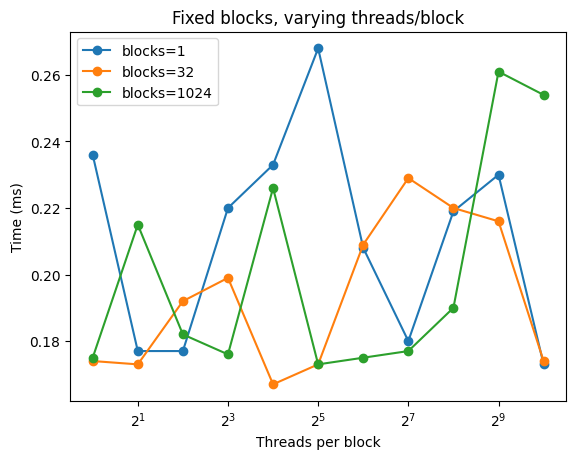

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("results.csv")

# Fix a few block counts, vary threads per block
fig, ax = plt.subplots()
for b in [1, 32, 1024]:
    subset = df[df["blocks"] == b].sort_values("threadsPerBlock")
    ax.plot(subset["threadsPerBlock"], subset["time_ms"], marker="o", label=f"blocks={b}")
ax.set_xscale("log", base=2)
ax.set_xlabel("Threads per block")
ax.set_ylabel("Time (ms)")
ax.legend()
ax.set_title("Fixed blocks, varying threads/block")
plt.show()